In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Primitive
A primitive is a layer between ideal circuit and its execution. Its job covers four main areas:

* It returns either probabilities (Sampler) or expectation values (Estimator).

* It automatically applies error-mitigation techniques like Readout Error Mitigation or Twirled Readout (T-REx).

* It optimizes how your circuits are bundled together. If you have 50 slightly different circuits, the primitive batches them efficiently to minimize "overhead" time on the fridge.

* On real IBM hardware, primitives allow you to open a Session. This keeps your "spot" on the quantum processor active, so you can run iterative loops (like training a Quantum Neural Network) without going back to the end of the public queue for every single iteration.

# Core Primitives
There are two main types of Primitives, designed for the two most common tasks in quantum computing:
## Sampler (For bitstrings and distributions)
The Sampler is used when you want to know the probability of measuring each state ($|00\rangle, |01\rangle$, etc.).
* **Input**: A Quantum Circuit.
* **Output**: A quasi-probability distribution.
* **Use Case**: Grover’s algorithm, Shor’s algorithm, or simple random number generation.
## Estimator (For physical properties/observables)
The Estimator is used when you want to calculate the "expectation value" of an operator (like energy or magnetism).
* **Input**: A Quantum Circuit + an Observable (e.g., a Pauli string like $ZZ$).
* **Output**: A single real number (the average value of that operator).
* **Use Case**: VQE (Variational Quantum Eigensolver), chemistry simulations, and QAOA.
## Implementation Tiers
You can run the same Primitive code on three different "engines":

* Reference Implementation: (e.g., `Sampler` from `qiskit.primitives`). Runs locally on your CPU; perfect for testing.

* Aer Implementation: (e.g., `AerSampler`). High-performance local simulation with noise models.

* Runtime Implementation: (e.g., `Sampler` from `qiskit_ibm_runtime`). Runs on actual IBM Quantum hardware with full error mitigation.

## Local sampler

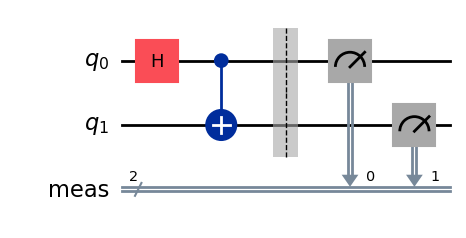

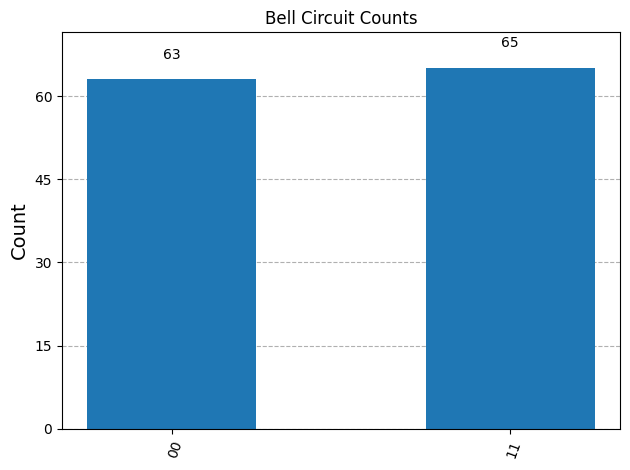

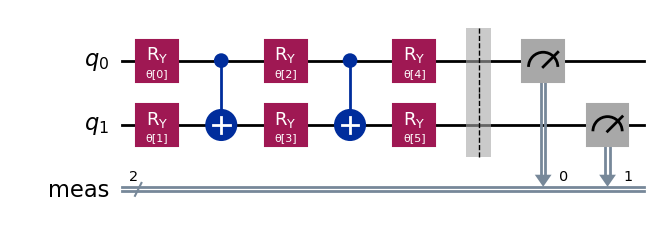

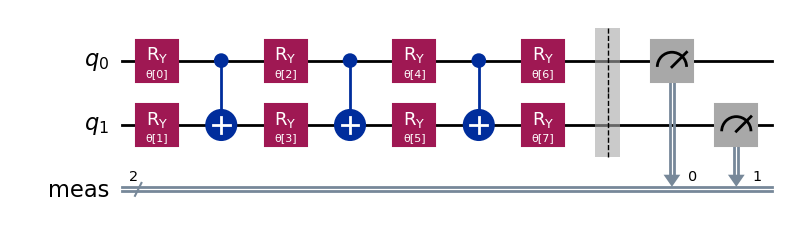

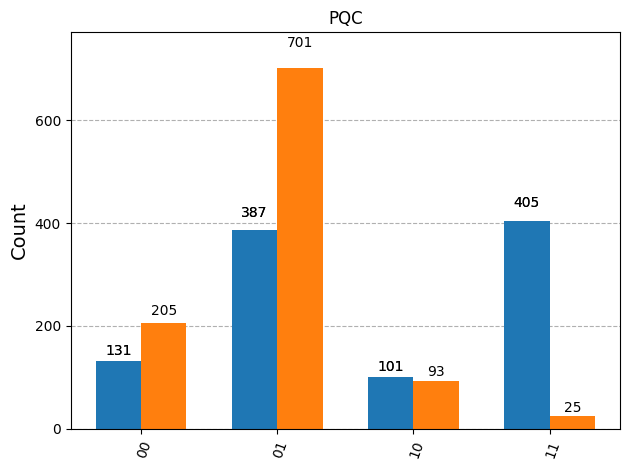

In [13]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit import QuantumCircuit
from qiskit.circuit.library import real_amplitudes
from qiskit.visualization import plot_histogram

# create a Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

display(bell.draw("mpl"))

# initialization of the sampler
sampler = Sampler()
# collect 128 shots from the Bell circuit
job = sampler.run([bell], shots=128)
job_result = job.result()
bell_data = job_result[0].data
bell_counts = bell_data.meas.get_counts()
display(plot_histogram(bell_counts, title="Bell Circuit Counts"))

# =========================================================
# create two parameterized circuits
pqc = real_amplitudes(num_qubits=2, reps=2)
pqc.measure_all()
pqc2 = real_amplitudes(num_qubits=2, reps=3)
pqc2.measure_all()
display(pqc.draw("mpl"))
display(pqc2.draw("mpl"))

theta1 = [0, 1, 1, 2, 3, 5]
theta2 = [0, 1, 2, 3, 4, 5, 6, 7]

# run a sampler job on the parameterized circuits
job2 = sampler.run([(pqc, theta1), (pqc2, theta2)])
job_result = job2.result()
pqc_data = job_result[0].data
pqc_counts = pqc_data.meas.get_counts()
pqc2_counts = job2.result()[1].data.meas.get_counts()
display(plot_histogram([pqc_counts, pqc2_counts], title="PQC")) 

# Local estimator
* Estimator computes the expectation value of an observable on the state or circuit.
* `SparsePauliOp` : Operator $H = II + 2 IZ + 3 XI$ will be passed as `[("II", 1), ("IZ", 2), ("XI", 3)]`

In [12]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp

pqc = real_amplitudes(num_qubits=2, reps=2)

H1 = SparsePauliOp.from_list([("II", 1), ("IZ", 2), ("XI", 3)])
H2 = SparsePauliOp.from_list([("IZ", 1)])
H3 = SparsePauliOp.from_list([("ZI", 1), ("ZZ", 1)])

estimator = Estimator()
# calculate [ <pqc(theta1)|H1|pqc(theta1)> ]
job = estimator.run([(pqc, H1, [theta1])])
job_result = job.result() # It will block until the job finishes.
print(f"The primitive-job finished with result {job_result[0].data.evs[0]}")

The primitive-job finished with result 1.5555572817900953
